# Bonus — Segmentation avancée par k-means sur les scores RFM

Ce notebook explore une approche non supervisée (k-means) comme alternative ou complément à la segmentation par règles métier.  
L'objectif est de laisser l'algorithme découvrir des groupes "naturels" dans l'espace RFM standardisé, puis de les interpréter.

**Plan :**
1. Chargement et standardisation des scores R, F, M
2. Méthode du coude + silhouette score pour choisir k
3. Entraînement du modèle k-means optimal
4. Visualisation des clusters (PCA 2D + scatter 3D)
5. Calcul de la Valeur Vie Client (CLV) simplifiée par cluster
6. Interprétation et recommandations

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')

rfm = pd.read_csv('data/rfm_segments.csv')
print(rfm.shape)
rfm.head()

(4314, 9)


,Customer ID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
0,12346.0,165,11,372.86,2,5,2,9,À risque
1,12347.0,3,2,1323.32,5,2,4,11,Nouveaux clients
2,12348.0,74,1,222.16,2,1,1,4,Autres
3,12349.0,43,3,2671.14,3,3,5,11,Autres
4,12351.0,11,1,300.93,5,1,2,8,Nouveaux clients


## 1. Standardisation des scores RFM

On utilise les scores discrets R, F, M (1–5) comme features.  
La standardisation (Z-score) est indispensable pour que k-means ne soit pas biaisé par l'échelle.

In [2]:
features = rfm[['R', 'F', 'M']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled = pd.DataFrame(X_scaled, columns=['R_scaled', 'F_scaled', 'M_scaled'])

print("Moyenne après standardisation :", X_scaled.mean().round(4).to_dict())
print("Écart-type après standardisation :", X_scaled.std().round(4).to_dict())
X_scaled.describe().round(3)

Moyenne après standardisation : {'R_scaled': -0.0, 'F_scaled': 0.0, 'M_scaled': 0.0}
Écart-type après standardisation : {'R_scaled': 1.0001, 'F_scaled': 1.0001, 'M_scaled': 1.0001}


,R_scaled,F_scaled,M_scaled
count,4314.000,4314.000,4314.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-1.421,-1.414,-1.414
25%,-0.719,-0.707,-0.707
50%,-0.017,0.000,0.000
75%,0.685,0.707,0.707
max,1.388,1.414,1.414


## 2. Méthode du coude et silhouette score

On teste k ∈ [2, 10] et on trace :
- l'**inertie** (somme des distances au centre — méthode du coude)
- le **silhouette score** (cohésion interne vs séparation inter-clusters, plus c'est proche de 1 mieux c'est)

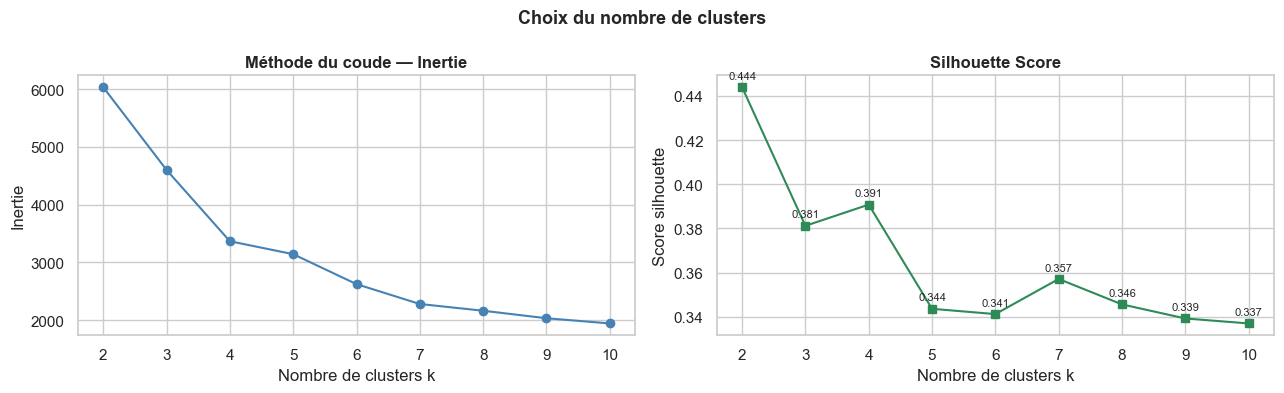

k optimal selon silhouette : 2 (score = 0.4440)


In [3]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(k_range), inertias, marker='o', color='steelblue')
ax1.set_title('Méthode du coude — Inertie', fontweight='bold')
ax1.set_xlabel('Nombre de clusters k')
ax1.set_ylabel('Inertie')

ax2.plot(list(k_range), silhouettes, marker='s', color='seagreen')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('Nombre de clusters k')
ax2.set_ylabel('Score silhouette')

for k, s in zip(k_range, silhouettes):
    ax2.annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0, 6),
                 ha='center', fontsize=8)

plt.suptitle('Choix du nombre de clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'k optimal selon silhouette : {best_k} (score = {max(silhouettes):.4f})')

## 3. Entraînement du k-means optimal

In [4]:
# Entraînement avec le meilleur k (silhouette)
# On peut aussi forcer k=4 ou k=5 pour aligner avec les segments métier
K_FINAL = best_k  # ou remplacer par un entier fixe

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init='auto')
rfm['Cluster'] = km_final.fit_predict(X_scaled)

# Profil moyen de chaque cluster
cluster_profile = rfm.groupby('Cluster').agg(
    n_clients=('Customer ID', 'count'),
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean'),
    avg_R=('R', 'mean'),
    avg_F=('F', 'mean'),
    avg_M=('M', 'mean'),
).round(1)

cluster_profile['pct'] = (cluster_profile['n_clients'] / len(rfm) * 100).round(1)
print(cluster_profile.to_string())

         n_clients  avg_recency  avg_frequency  avg_monetary  avg_R  avg_F  avg_M   pct
Cluster                                                                                
0             2243        139.6            1.5         422.2    2.2    1.9    1.9  52.0
1             2071         38.9            7.7        3807.3    3.9    4.2    4.2  48.0


## 4. Visualisation des clusters

### 4a. Projection PCA 2D

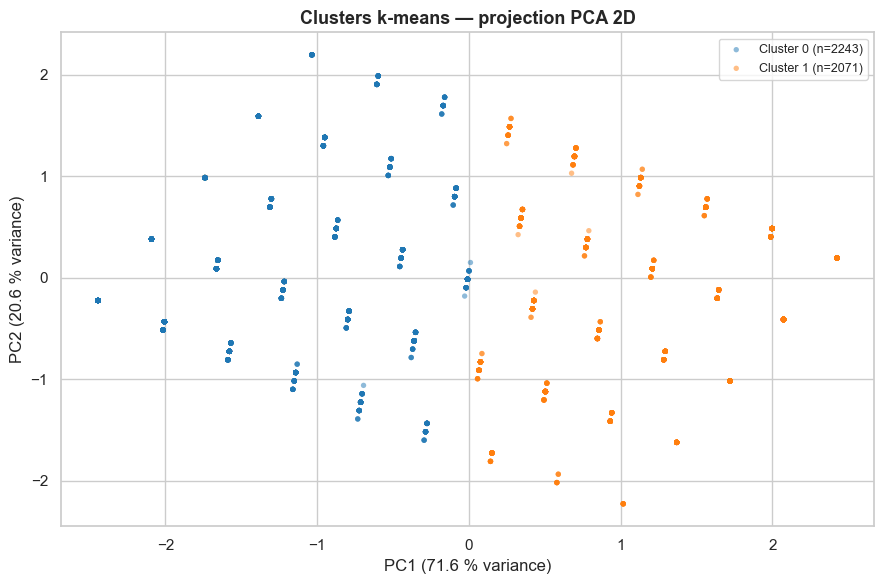

Variance expliquée (PC1+PC2) : 92.2 %


In [5]:
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('tab10', K_FINAL)

for c in range(K_FINAL):
    mask = rfm['Cluster'] == c
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               label=f'Cluster {c} (n={mask.sum()})',
               color=palette[c], alpha=0.5, s=15, edgecolors='none')

ax.set_title('Clusters k-means — projection PCA 2D', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f} % variance)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f} % variance)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Variance expliquée (PC1+PC2) : {sum(explained)*100:.1f} %')

### 4b. Heatmap des centres de clusters (scores R, F, M moyens)

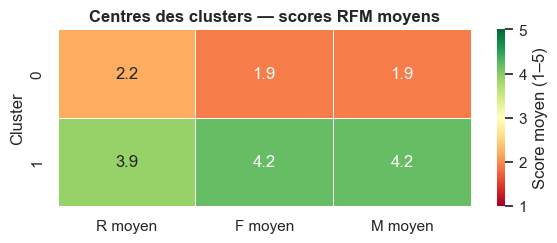

In [6]:
centers_df = cluster_profile[['avg_R', 'avg_F', 'avg_M']].rename(
    columns={'avg_R': 'R moyen', 'avg_F': 'F moyen', 'avg_M': 'M moyen'}
)

fig, ax = plt.subplots(figsize=(6, K_FINAL * 0.8 + 1))
sns.heatmap(
    centers_df,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=1, vmax=5,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Score moyen (1–5)'}
)
ax.set_title('Centres des clusters — scores RFM moyens', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

## 5. Valeur Vie Client (CLV) simplifiée par cluster

La CLV sur une fenêtre de 12 mois est estimée par la formule simple :

$$\text{CLV}_{12m} = \text{Fréquence annuelle} \times \text{Panier moyen} \times \text{Marge brute}$$

On suppose une **marge brute de 20 %** et on annualise la fréquence observée sur la période de données (~13 mois).

> **Note** : une estimation plus précise nécessite un modèle probabiliste (BG/NBD pour la fréquence + Gamma-Gamma pour le montant).

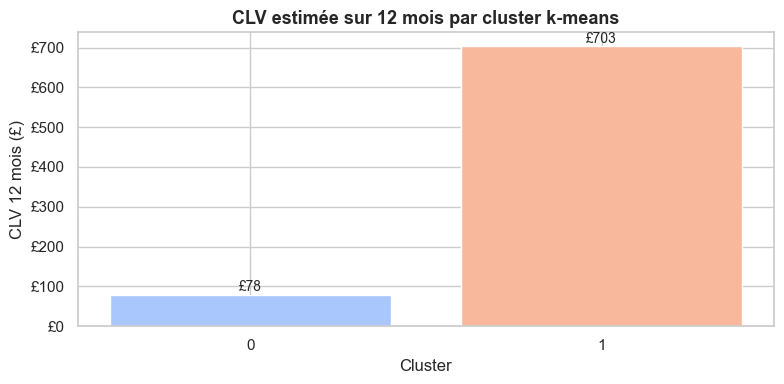


Résumé CLV par cluster :
         n_clients   pct  avg_recency  avg_frequency  avg_monetary  CLV_12m
Cluster                                                                    
0             2243  52.0        139.6            1.5         422.2     78.0
1             2071  48.0         38.9            7.7        3807.3    703.0


In [7]:
DATA_PERIOD_MONTHS = 13  # durée approximative du jeu de données
GROSS_MARGIN = 0.20

clv = cluster_profile.copy()
clv['avg_basket'] = clv['avg_monetary'] / clv['avg_frequency']
clv['annual_freq'] = clv['avg_frequency'] / DATA_PERIOD_MONTHS * 12
clv['CLV_12m'] = (clv['annual_freq'] * clv['avg_basket'] * GROSS_MARGIN).round(0)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('coolwarm', K_FINAL)
bars = ax.bar(clv.index.astype(str), clv['CLV_12m'], color=colors, edgecolor='white')

for bar, val in zip(bars, clv['CLV_12m']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'£{val:,.0f}', ha='center', va='bottom', fontsize=10)

ax.set_title('CLV estimée sur 12 mois par cluster k-means', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('CLV 12 mois (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

print("\nRésumé CLV par cluster :")
print(clv[['n_clients', 'pct', 'avg_recency', 'avg_frequency', 'avg_monetary', 'CLV_12m']].to_string())

## 6. Comparaison : segments métier vs clusters k-means

Croiser les deux approches pour vérifier leur cohérence et détecter d'éventuels sous-groupes masqués.

Cluster                    0     1   All
Segment                                 
Autres                  1446   364  1810
Baleines                   0   926   926
Clients fidèles actifs    65   402   467
Clients perdus            72   282   354
Nouveaux clients         322    44   366
À risque                 338    53   391
All                     2243  2071  4314


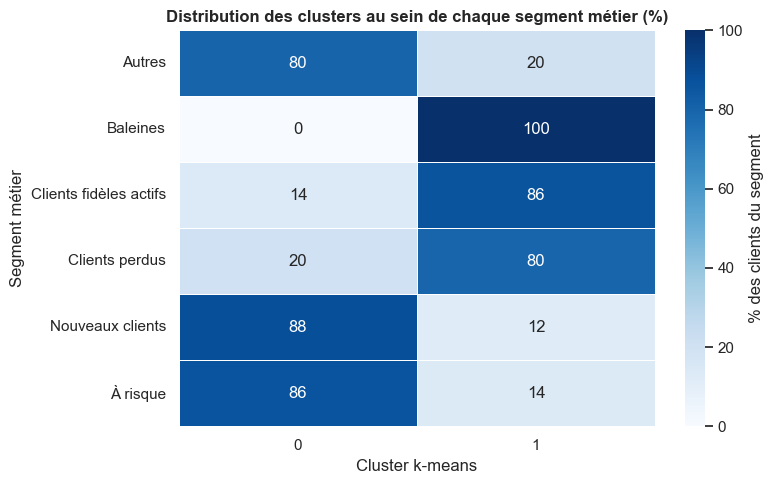

In [8]:
cross = pd.crosstab(rfm['Segment'], rfm['Cluster'], margins=True)
print(cross.to_string())

fig, ax = plt.subplots(figsize=(max(8, K_FINAL + 3), 5))
cross_pct = pd.crosstab(rfm['Segment'], rfm['Cluster'], normalize='index') * 100
sns.heatmap(cross_pct.drop('All', errors='ignore'),
            annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '% des clients du segment'})
ax.set_title('Distribution des clusters au sein de chaque segment métier (%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster k-means')
ax.set_ylabel('Segment métier')
plt.tight_layout()
plt.show()

## 7. Synthèse et recommandations

### Avantages du k-means sur la segmentation par règles
- Découvre des groupes **statistiquement homogènes** sans imposer de seuils a priori.
- Peut révéler des **sous-segments** non visibles avec les règles métier (ex. : un cluster "Baleines inactives" distinct de "Clients perdus").
- Facilement **scalable** et automatisable dans un pipeline.

### Limites
- Les clusters k-means ne sont pas **interprétables directement** — il faut les nommer a posteriori.
- Sensible à l'**initialisation** et au choix de k.
- Les scores R, F, M discrets (1–5) réduisent la dimensionnalité effective → résultats souvent similaires à la segmentation par règles.

### Recommandation finale
Utiliser **les deux approches en parallèle** :
- La segmentation par règles pour la communication marketing (noms lisibles par les équipes métier).
- Le k-means pour le ciblage prédictif et la détection de sous-groupes à fort potentiel.

### Prochaine étape : CLV probabiliste (BG/NBD)
Pour une estimation plus robuste de la valeur vie client, implémenter le modèle **Beta Geometric / Negative Binomial Distribution** (bibliothèque `lifetimes`) qui modélise explicitement la probabilité qu'un client soit encore actif.